# 1. Exploratory Data Analysis (EDA)

The goal of this section is to understand the structure and characteristics of the Bosch Manufacturing Defect dataset before building predictive models.

The EDA focuses on:

- Understanding the dataset structure
- Examining manufacturing defect distribution
- Investigating missing value patterns
- Exploring feature availability
- Identifying features related to defect occurrence
- Generating insights for feature engineering and modeling

## 1.1 Basic Structure Check

The Bosch Production Line dataset contains measurements collected from multiple manufacturing stations.

Each row represents a single manufactured product.

Key columns include:

- **Id**: unique identifier for each product
- **Response**: defect label
    - 0 = Passed inspection
    - 1 = Failed inspection
- Hundreds of measurement features collected throughout the production process

The objective is to predict whether a product will fail quality inspection based on these measurements.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [2]:
train = pd.read_csv(
    "/Users/junghanlee/Downloads/1. Python Code/3. Manufacturing Defect Prediction/1. Data/raw/train_numeric.csv"
)

train.head()

,Id,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,L0_S0_F18,L0_S0_F20,L0_S0_F22,L0_S1_F24,L0_S1_F28,L0_S2_F32,L0_S2_F36,L0_S2_F40,L0_S2_F44,L0_S2_F48,L0_S2_F52,L0_S2_F56,L0_S2_F60,L0_S2_F64,L0_S3_F68,L0_S3_F72,L0_S3_F76,L0_S3_F80,L0_S3_F84,L0_S3_F88,L0_S3_F92,L0_S3_F96,L0_S3_F100,L0_S4_F104,L0_S4_F109,L0_S5_F114,L0_S5_F116,L0_S6_F118,L0_S6_F122,L0_S6_F132,L0_S7_F136,L0_S7_F138,L0_S7_F142,L0_S8_F144,L0_S8_F146,L0_S8_F149,L0_S9_F155,L0_S9_F160,L0_S9_F165,L0_S9_F170,L0_S9_F175,L0_S9_F180,L0_S9_F185,L0_S9_F190,L0_S9_F195,L0_S9_F200,L0_S9_F205,L0_S9_F210,L0_S10_F219,L0_S10_F224,L0_S10_F229,L0_S10_F234,L0_S10_F239,L0_S10_F244,L0_S10_F249,L0_S10_F254,L0_S10_F259,L0_S10_F264,L0_S10_F269,L0_S10_F274,L0_S11_F282,L0_S11_F286,L0_S11_F290,L0_S11_F294,L0_S11_F298,L0_S11_F302,L0_S11_F306,L0_S11_F310,L0_S11_F314,L0_S11_F318,L0_S11_F322,L0_S11_F326,L0_S12_F330,L0_S12_F332,L0_S12_F334,L0_S12_F336,L0_S12_F338,L0_S12_F340,L0_S12_F342,L0_S12_F344,L0_S12_F346,L0_S12_F348,L0_S12_F350,L0_S12_F352,L0_S13_F354,L0_S13_F356,L0_S14_F358,L0_S14_F362,L0_S14_F366,L0_S14_F370,L0_S14_F374,L0_S14_F378,L0_S14_F382,L0_S14_F386,L0_S14_F390,L0_S15_F394,L0_S15_F397,L0_S15_F400,L0_S15_F403,L0_S15_F406,L0_S15_F409,L0_S15_F412,L0_S15_F415,L0_S15_F418,L0_S16_F421,L0_S16_F426,L0_S17_F431,L0_S17_F433,L0_S18_F435,L0_S18_F439,L0_S18_F449,L0_S19_F453,L0_S19_F455,L0_S19_F459,L0_S20_F461,L0_S20_F463,L0_S20_F466,L0_S21_F472,L0_S21_F477,L0_S21_F482,L0_S21_F487,L0_S21_F492,L0_S21_F497,L0_S21_F502,L0_S21_F507,L0_S21_F512,L0_S21_F517,L0_S21_F522,L0_S21_F527,L0_S21_F532,L0_S21_F537,L0_S22_F546,L0_S22_F551,L0_S22_F556,L0_S22_F561,L0_S22_F566,L0_S22_F571,L0_S22_F576,L0_S22_F581,L0_S22_F586,L0_S22_F591,L0_S22_F596,L0_S22_F601,L0_S22_F606,L0_S22_F611,L0_S23_F619,L0_S23_F623,L0_S23_F627,L0_S23_F631,L0_S23_F635,L0_S23_F639,L0_S23_F643,L0_S23_F647,L0_S23_F651,L0_S23_F655,L0_S23_F659,L0_S23_F663,L0_S23_F667,L0_S23_F671,L1_S24_F679,L1_S24_F683,L1_S24_F687,L1_S24_F691,L1_S24_F700,L1_S24_F719,L1_S24_F728,L1_S24_F733,L1_S24_F746,L1_S24_F751,L1_S24_F756,L1_S24_F761,L1_S24_F766,L1_S24_F775,L1_S24_F780,L1_S24_F785,L1_S24_F790,L1_S24_F795,L1_S24_F800,L1_S24_F802,L1_S24_F806,L1_S24_F808,L1_S24_F810,L1_S24_F812,L1_S24_F814,L1_S24_F816,L1_S24_F829,L1_S24_F834,L1_S24_F839,L1_S24_F844,L1_S24_F857,L1_S24_F862,L1_S24_F867,L1_S24_F872,L1_S24_F877,L1_S24_F882,L1_S24_F887,L1_S24_F892,L1_S24_F897,L1_S24_F902,L1_S24_F907,L1_S24_F920,L1_S24_F925,L1_S24_F930,L1_S24_F935,L1_S24_F948,L1_S24_F953,L1_S24_F958,L1_S24_F963,L1_S24_F968,L1_S24_F973,L1_S24_F978,L1_S24_F983,L1_S24_F988,L1_S24_F993,L1_S24_F998,L1_S24_F1000,L1_S24_F1002,L1_S24_F1004,L1_S24_F1006,L1_S24_F1008,L1_S24_F1010,L1_S24_F1012,L1_S24_F1014,L1_S24_F1016,L1_S24_F1021,L1_S24_F1026,L1_S24_F1031,L1_S24_F1036,L1_S24_F1041,L1_S24_F1046,L1_S24_F1051,L1_S24_F1056,L1_S24_F1068,L1_S24_F1072,L1_S24_F1079,L1_S24_F1083,L1_S24_F1087,L1_S24_F1094,L1_S24_F1098,L1_S24_F1102,L1_S24_F1106,L1_S24_F1110,L1_S24_F1118,L1_S24_F1122,L1_S24_F1126,L1_S24_F1130,L1_S24_F1134,L1_S24_F1145,L1_S24_F1148,L1_S24_F1161,L1_S24_F1166,L1_S24_F1170,L1_S24_F1172,L1_S24_F1174,L1_S24_F1176,L1_S24_F1180,L1_S24_F1184,L1_S24_F1197,L1_S24_F1202,L1_S24_F1207,L1_S24_F1212,L1_S24_F1225,L1_S24_F1230,L1_S24_F1235,L1_S24_F1240,L1_S24_F1245,L1_S24_F1250,L1_S24_F1255,L1_S24_F1260,L1_S24_F1265,L1_S24_F1270,L1_S24_F1275,L1_S24_F1288,L1_S24_F1293,L1_S24_F1298,L1_S24_F1303,L1_S24_F1316,L1_S24_F1321,L1_S24_F1326,L1_S24_F1331,L1_S24_F1336,L1_S24_F1341,L1_S24_F1346,L1_S24_F1351,L1_S24_F1356,L1_S24_F1361,L1_S24_F1366,L1_S24_F1371,L1_S24_F1376,L1_S24_F1381,L1_S24_F1386,L1_S24_F1391,L1_S24_F1396,L1_S24_F1401,L1_S24_F1406,L1_S24_F1411,L1_S24_F1416,L1_S24_F1421,L1_S24_F1426,L1_S24_F1431,L1_S24_F1436,L1_S24_F1441,L1_S24_F1446,L1_S24_F1451,L1_S24_F1463,L1_S24_F1467,L1_S24_F1474,L1_S24_F1478,L1_S24_F1482,L1_S24_F1486,L1_S24_F1490,L1_S24_F1494,L1_S24_F1498,L1_S24_F1502,L1_S24_F1506,L1_S24_F1512,L1_S24_F1514,L1_S24_F1516,L1_S24_F1518,L1_S24_F1520,L1_S24_F1539,L1_S24_F1544,L1_S24_F15

In [3]:
train.shape

(1183747, 970)

## 1.2 Dataset Overview

Before performing analysis, it is important to understand the overall structure of the dataset, including data types and basic statistics.

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1183747 entries, 0 to 1183746
Columns: 970 entries, Id to Response
dtypes: float64(968), int64(2)
memory usage: 8.6 GB


In [5]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1183747.0,1.184050e+06,683434.767725,4.000,592138.500,1184628.000,1775674.500,2367495.000
L0_S0_F0,673862.0,5.456013e-05,0.080214,-0.565,-0.049,0.003,0.056,0.278
L0_S0_F2,673862.0,9.128575e-05,0.092799,-0.616,-0.056,0.004,0.063,0.302
L0_S0_F4,673862.0,4.005271e-05,0.211520,-0.415,-0.179,-0.033,0.294,0.585
L0_S0_F6,673862.0,1.383518e-05,0.211635,-0.416,-0.179,-0.034,0.294,0.584
...,...,...,...,...,...,...,...,...
L3_S51_F4256,59853.0,-2.171988e-06,0.000716,-0.001,0.000,0.000,0.000,0.173
L3_S51_F4258,59853.0,3.732478e-05,0.005785,0.000,0.000,0.000,0.000,1.000
L3_S51_F4260,59853.0,2.160627e-04,0.008295,0.000,0.000,0.000,0.000,1.000
L3_S51_F4262,59853.0,5.627120e-05,0.004196,0.000,0.000,0.000,0.000,1.000


## 1.3 Missing Value Analysis

In manufacturing environments, measurements are often collected only at specific stations.

As a result, many features are expected to contain missing values depending on the production path followed by each product.

In [6]:
missing_ratio = train.isnull().mean()

missing_ratio.sort_values(
    ascending=False
).head(20)

L1_S25_F2184    0.998950
L1_S25_F2202    0.998950
L1_S25_F2181    0.998950
L1_S25_F2187    0.998950
L1_S25_F2190    0.998950
L1_S25_F2193    0.998950
L1_S25_F2196    0.998950
L1_S25_F2199    0.998950
L1_S25_F2712    0.998212
L1_S25_F2714    0.998212
L1_S25_F2716    0.998212
L1_S25_F2718    0.998212
L1_S25_F2720    0.998212
L1_S25_F2724    0.998212
L1_S25_F2726    0.998212
L1_S25_F2722    0.998212
L1_S25_F2559    0.998186
L1_S25_F2535    0.998186
L1_S25_F2564    0.998186
L1_S25_F2584    0.998186
dtype: float64

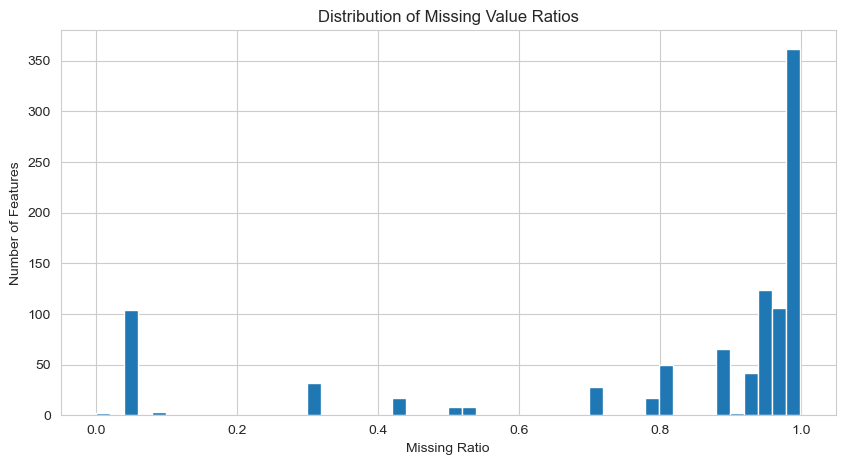

In [7]:
plt.figure(figsize=(10,5))

missing_ratio.hist(bins=50)

plt.title("Distribution of Missing Value Ratios")
plt.xlabel("Missing Ratio")
plt.ylabel("Number of Features")

plt.show()

### Observation

A significant portion of features contain high missing value ratios.

This likely reflects manufacturing routing logic, where products pass through different production stations.

## 1.4 Target Variable Analysis

Understanding the distribution of defective products is essential before model development.

Manufacturing defect datasets are typically highly imbalanced because failures occur relatively infrequently.

In [8]:
train["Response"].value_counts()

Response
0    1176868
1       6879
Name: count, dtype: int64

In [9]:
train["Response"].value_counts(
    normalize=True
) * 100

Response
0    99.418879
1     0.581121
Name: proportion, dtype: float64

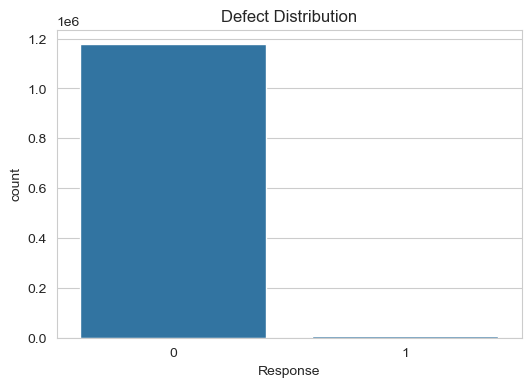

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Response",
    data=train
)

plt.title("Defect Distribution")

plt.show()

### Observation

The dataset is highly imbalanced, with defective products representing only a small percentage of observations.

This imbalance will require special consideration during model training and evaluation.

## 1.5 Feature Availability Analysis

Features with lower missing value ratios may provide more reliable information during model development.

In [11]:
low_missing_features = missing_ratio[
    missing_ratio < 0.05
]

len(low_missing_features)

2

In [12]:
low_missing_features.head(20)

Id          0.0
Response    0.0
dtype: float64

## 1.6 Correlation Analysis

This section explores the relationship between manufacturing measurements and defect outcomes.

In [21]:
sample = train.sample(
    n=100000,
    random_state=42
)

correlation = sample.drop(
    columns=["Id"]
).corrwith(
    sample["Response"]
).abs()

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 1.7 Feature Distribution Analysis

The Bosch dataset is very large, so visualizing feature distributions using the full dataset can be computationally expensive.

For EDA purposes, a random sample of 100,000 rows is used. This allows us to examine feature patterns efficiently while still preserving the overall data characteristics.

In [22]:
sample = train.sample(
    n=100000,
    random_state=42
)

print(f"Original dataset shape: {train.shape}")
print(f"EDA sample shape: {sample.shape}")

Original dataset shape: (1183747, 970)
EDA sample shape: (100000, 970)


In [23]:
top_features = (
    correlation
    .sort_values(ascending=False)
    .head(11)
    .index
)

top_features = [
    col
    for col in top_features
    if col != "Response"
]

top_features

['L1_S24_F867',
 'L1_S25_F2707',
 'L1_S24_F839',
 'L1_S24_F1723',
 'L1_S25_F2662',
 'L1_S24_F902',
 'L1_S25_F2632',
 'L1_S25_F2692',
 'L1_S25_F2857',
 'L1_S25_F2637']

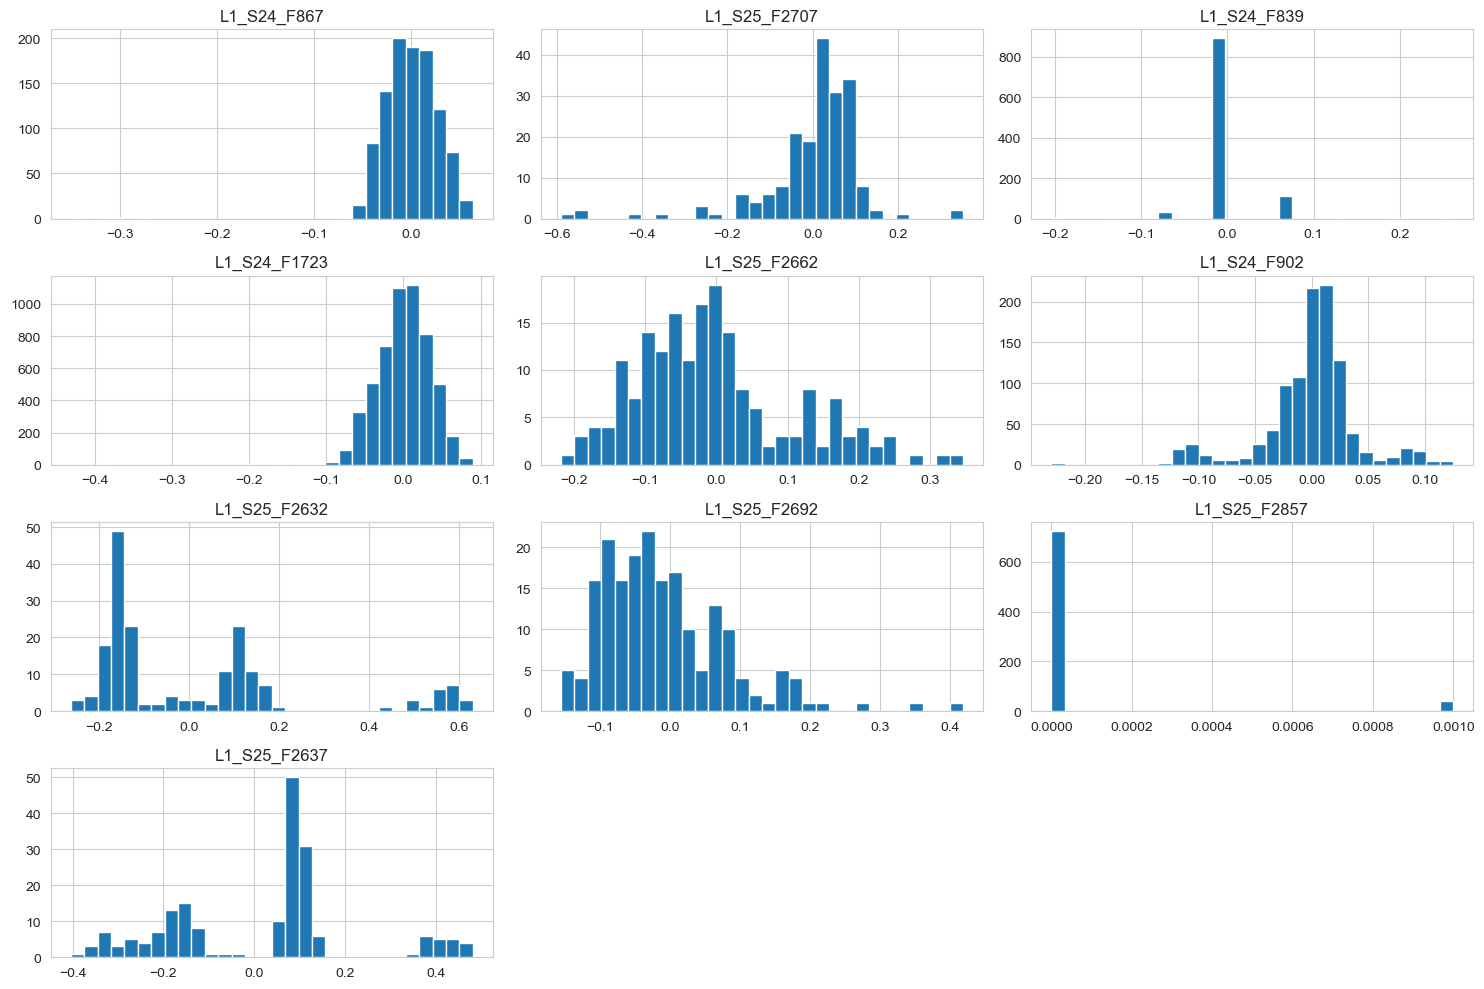

In [24]:
sample[top_features].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

### Observation

The selected features show different distribution patterns across manufacturing measurements.

Some features may contain skewed distributions or repeated values, which is common in production line data where measurements are collected under specific process conditions.

## Top Feature Correlation Heatmap

The heatmap below shows relationships among the most correlated features identified during EDA.

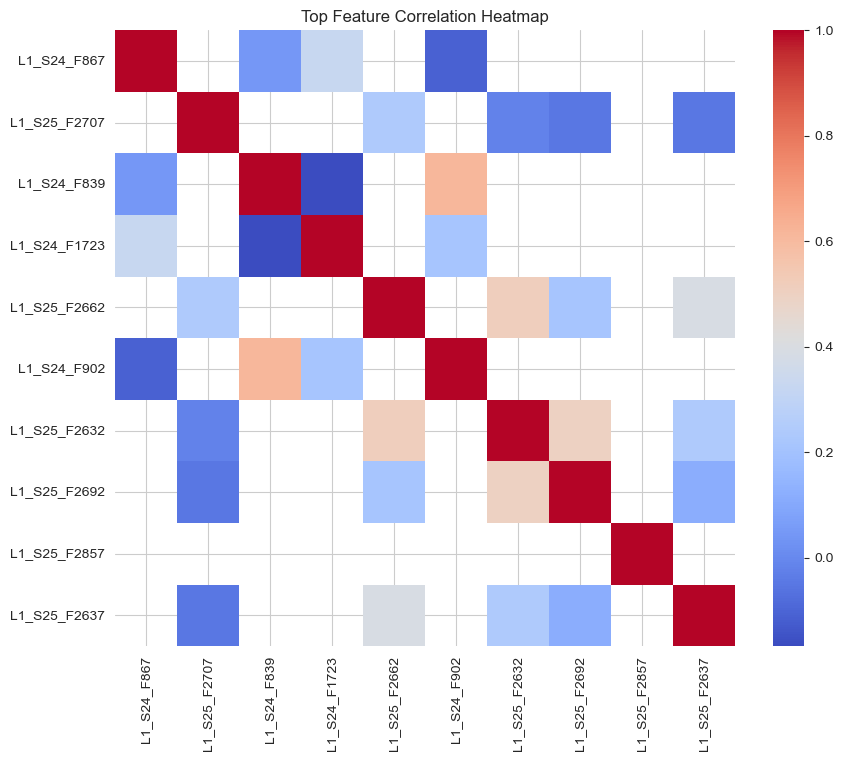

In [26]:
plt.figure(figsize=(10,8))

sns.heatmap(
    sample[top_features].corr(),
    cmap="coolwarm"
)

plt.title("Top Feature Correlation Heatmap")

plt.show()

### Observation

No severe multicollinearity was observed among the selected features.

Most feature pairs exhibit weak to moderate correlations, suggesting that they may provide complementary information for defect prediction.

Several measurements collected from the same production stations (e.g., Station 24 and Station 25) show moderate positive correlations, which is expected due to shared manufacturing processes.